## Pipelines and auto classes
**Pipelines**: `pipeline()`,
- Streamlines tasks
- Automatic model and tokenizer selection
- Limited control

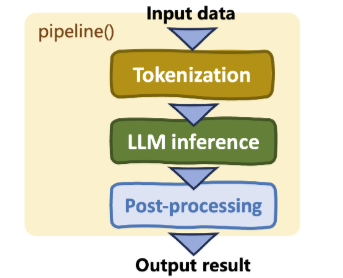

## Auto classes (`AutoModel` class)
- Customization
- Manual adjustments
- Supports fine-tuning

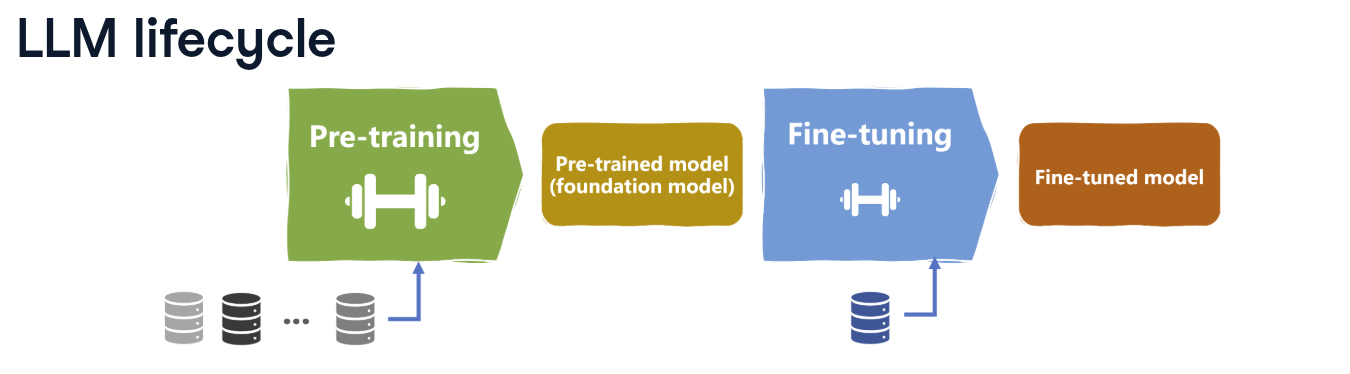

### Pre-training
- Broad data
- Learn general patterns

### Fine-tuning
- Domain specific
- Specialized tasks

## Loading a dataset for fine-tuning
- `load_dataset()`: loads a dataset from Hugging Face hub
    - **imdb**: movie reviews classification dataset


In [18]:
from datasets import load_dataset

train_data = load_dataset('imdb', split='train')
train_data = train_data.shard(num_shards=4, index=0)
test_data = load_dataset('imdb', split='test')
test_data = test_data.shard(num_shards=4, index=0)

'(ProtocolError('Connection aborted.', RemoteDisconnected('Remote end closed connection without response')), '(Request ID: c1d7bb2f-40a5-4a21-8d28-452ed73399fb)')' thrown while requesting HEAD https://huggingface.co/datasets/imdb/resolve/main/README.md
Retrying in 1s [Retry 1/5].


## Auto classes

In [19]:
from transformers import AutoModel, AutoTokenizer
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased')
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [20]:
# Tokenize the data
tokenized_training_data = tokenizer(list(train_data['text']), return_tensors='pt', padding=True, truncation=True, max_length=64)

tokenized_test_data = tokenizer(list(test_data['text']), return_tensors='pt', padding=True, truncation=True, max_length=64)

### Tokenization output

In [21]:
print(tokenized_training_data)

{'input_ids': tensor([[  101,  1045, 12524,  ...,  1000,  1045,   102],
        [  101,  1000,  1045,  ...,  1005,  1056,   102],
        [  101,  2065,  2069,  ..., 11795,  3085,   102],
        ...,
        [  101, 17012,  1010,  ...,  2668,  8631,   102],
        [  101,  2066,  2087,  ...,  2781,  1012,   102],
        [  101,  1045,  2079,  ...,  1997,  2014,   102]]), 'token_type_ids': tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        ...,
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1]])}


## Tokenizing row by row

In [22]:
def tokenize_function(text_data):
    return tokenizer(text_data['text'], return_tensors='pt', padding=True, truncation=True, max_length=64)

In [23]:
# Tokenize in batches
tokenized_in_batches = train_data.map(tokenize_function, batched=True)

# tokenize row by row
tokenized_by_row = train_data.map(tokenize_function, batched=False)

Map:   0%|          | 0/6250 [00:00<?, ? examples/s]

In [24]:
tokenized_in_batches

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 6250
})

## Subword tokenization
- Common in modern tokenizers
- Words split into meaningful sub-parts of a word including prefixes and suffixes